In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Try different separator
df = pd.read_csv('./open-meteo-48.22N14.70E251m.csv', sep=';')

# Inspect columns
df.columns

Index(['latitude,longitude,elevation,utc_offset_seconds,timezone,timezone_abbreviation'], dtype='str')

In [2]:
# Skip metadata rows
df = pd.read_csv('./open-meteo-48.22N14.70E251m.csv', skiprows=3)

df.head()

,time,temperature_2m (°C),precipitation (mm),relative_humidity_2m (%),dew_point_2m (°C),wind_speed_10m (km/h),soil_temperature_0cm (°C)
0,2026-04-10T00:00,2.3,0.0,68,-3.0,7.0,1.8
1,2026-04-10T01:00,2.0,0.0,65,-3.8,8.7,1.8
2,2026-04-10T02:00,1.9,0.0,63,-4.4,8.9,2.2
3,2026-04-10T03:00,2.3,0.0,60,-4.7,8.2,2.9
4,2026-04-10T04:00,2.5,0.0,57,-5.1,8.7,3.1


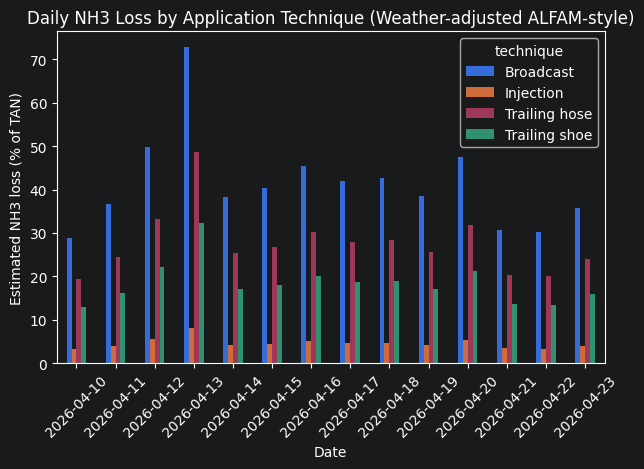

In [3]:
# Process data
df['time'] = pd.to_datetime(df['time'])
df['date'] = df['time'].dt.date

daily = df.groupby('date').agg({
    'temperature_2m (°C)': 'mean',
    'wind_speed_10m (km/h)': 'mean',
    'relative_humidity_2m (%)': 'mean'
}).reset_index()

def estimate_loss(base, temp, wind, rh):
    return base * (1 + 0.03*(temp-10)) * (1 + 0.02*(wind-5)) * (1 - 0.01*(rh-60))

bases = {
    "Broadcast": 45,
    "Trailing hose": 30,
    "Trailing shoe": 20,
    "Injection": 5
}

results = []
for _, row in daily.iterrows():
    for tech, base in bases.items():
        loss = estimate_loss(base, row['temperature_2m (°C)'],
                             row['wind_speed_10m (km/h)'],
                             row['relative_humidity_2m (%)'])
        results.append({
            "date": row['date'],
            "technique": tech,
            "loss": max(loss, 0)
        })

res_df = pd.DataFrame(results)
pivot = res_df.pivot(index='date', columns='technique', values='loss')

pivot.plot(kind='bar')
plt.xlabel("Date")
plt.ylabel("Estimated NH3 loss (% of TAN)")
plt.title("Daily NH3 Loss by Application Technique (Weather-adjusted ALFAM-style)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

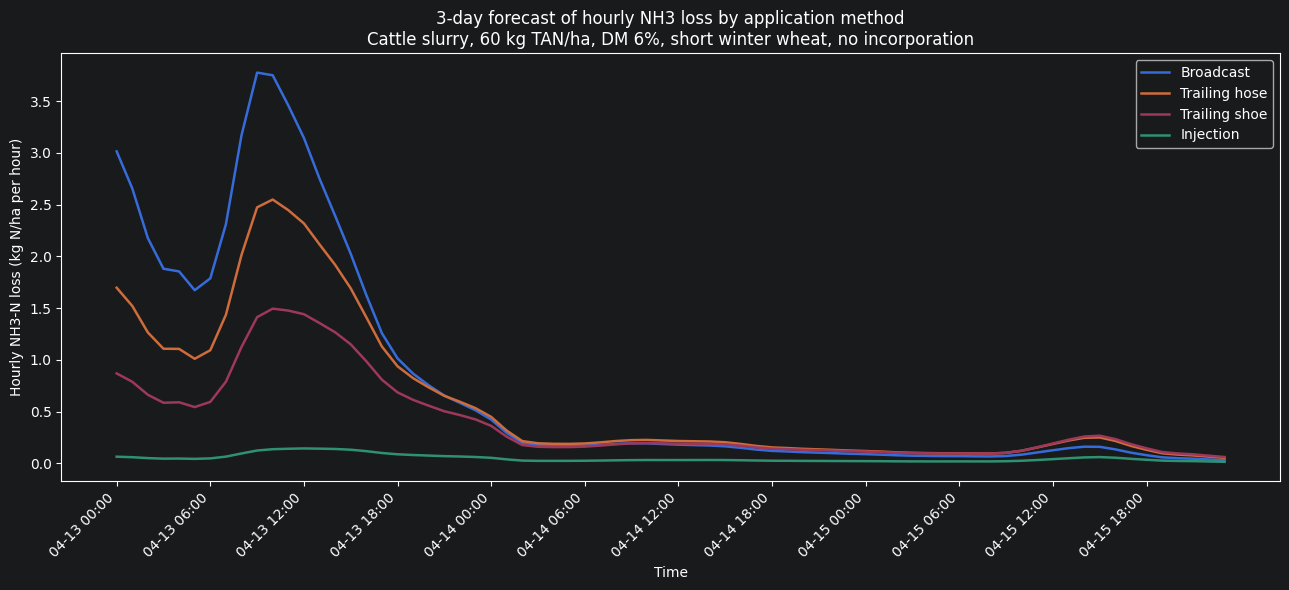

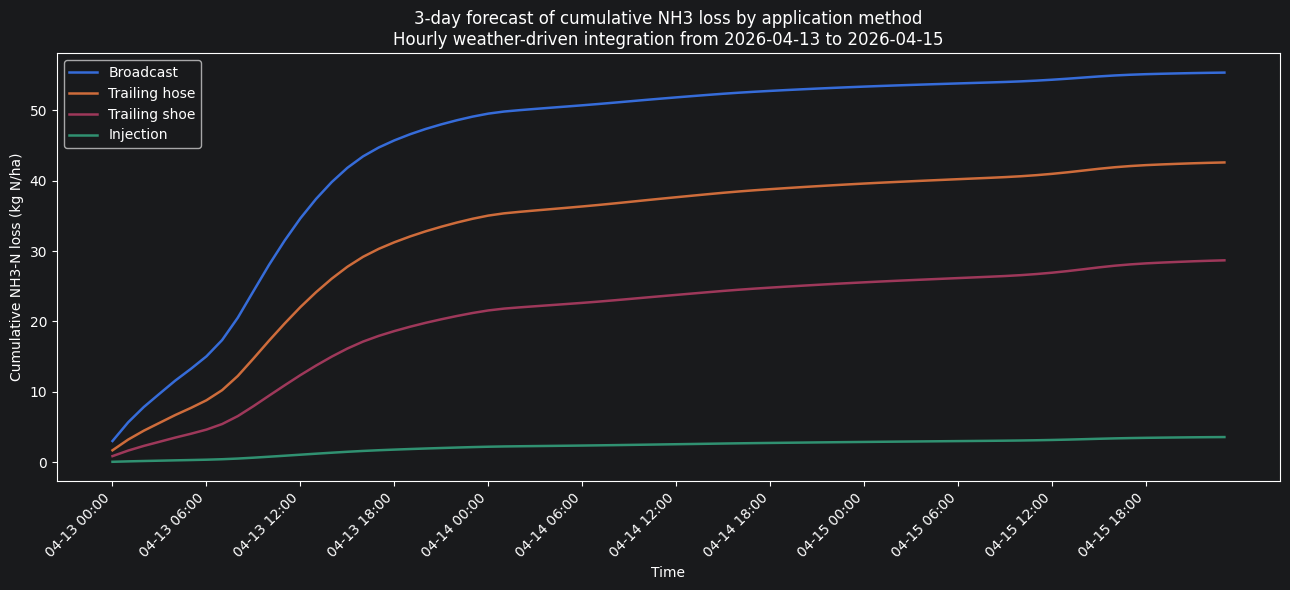

    Technique  3-day NH3-N loss (kg N/ha)  3-day NH3 loss (% of 60 kg TAN/ha)
    Broadcast                       55.35                                92.2
Trailing hose                       42.58                                71.0
Trailing shoe                       28.68                                47.8
    Injection                        3.58                                 6.0


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load hourly weather data
df = pd.read_csv('./open-meteo-48.22N14.70E251m.csv', skiprows=3)
df['time'] = pd.to_datetime(df['time'])

# Select 3-day forecast window starting 2026-04-13 00:00
start = pd.Timestamp('2026-04-13 00:00')
end = pd.Timestamp('2026-04-16 00:00')
window = df[(df['time'] >= start) & (df['time'] < end)].copy().reset_index(drop=True)

# Weather series
temp = window['temperature_2m (°C)'].astype(float).to_numpy()
wind = window['wind_speed_10m (km/h)'].astype(float).to_numpy()
rh = window['relative_humidity_2m (%)'].astype(float).to_numpy()
rain = window['rain (mm)'].astype(float).to_numpy() if 'rain (mm)' in window.columns else np.zeros(len(window))
labels = window['time'].dt.strftime('%m-%d %H:%M').to_list()

# Scenario
TAN_applied = 60.0  # kg TAN/ha

# Technique-specific settings
tech_factors = {
    'Broadcast': 1.00,
    'Trailing hose': 0.68,
    'Trailing shoe': 0.45,
    'Injection': 0.10,
}

available_pool_fraction = {
    'Broadcast': 0.95,
    'Trailing hose': 0.78,
    'Trailing shoe': 0.60,
    'Injection': 0.20,
}

def hourly_hazard(temp_c, wind_kmh, rh_pct, rain_mm):
    f_temp = np.exp(0.055 * (temp_c - 10.0))
    f_wind = 1.0 + 0.035 * wind_kmh
    f_rh = np.exp(-0.012 * (rh_pct - 60.0))
    f_rain = np.exp(-0.75 * rain_mm)
    return f_temp * f_wind * f_rh * f_rain

haz = hourly_hazard(temp, wind, rh, rain)
k0 = 0.030

hourly_losses = {}
cumulative_losses = {}

for tech, exposure in tech_factors.items():
    remaining = TAN_applied * available_pool_fraction[tech]
    hourly = []
    cumulative = []
    total = 0.0

    for i in range(len(window)):
        k = min(k0 * exposure * haz[i], 0.45)
        loss = remaining * (1.0 - np.exp(-k))
        total += loss
        remaining -= loss
        hourly.append(loss)
        cumulative.append(total)

    hourly_losses[tech] = np.array(hourly)
    cumulative_losses[tech] = np.array(cumulative)

# Plot hourly loss over 3 days
plt.figure(figsize=(13, 6))
for tech in ['Broadcast', 'Trailing hose', 'Trailing shoe', 'Injection']:
    plt.plot(range(len(window)), hourly_losses[tech], linewidth=1.8, label=tech)

tick_idx = list(range(0, len(window), 6))
tick_labels = [labels[i] for i in tick_idx]

plt.xlabel('Time')
plt.ylabel('Hourly NH3-N loss (kg N/ha per hour)')
plt.title('3-day forecast of hourly NH3 loss by application method\nCattle slurry, 60 kg TAN/ha, DM 6%, short winter wheat, no incorporation')
plt.xticks(tick_idx, tick_labels, rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

# Plot cumulative loss over 3 days
plt.figure(figsize=(13, 6))
for tech in ['Broadcast', 'Trailing hose', 'Trailing shoe', 'Injection']:
    plt.plot(range(len(window)), cumulative_losses[tech], linewidth=1.8, label=tech)

plt.xlabel('Time')
plt.ylabel('Cumulative NH3-N loss (kg N/ha)')
plt.title('3-day forecast of cumulative NH3 loss by application method\nHourly weather-driven integration from 2026-04-13 to 2026-04-15')
plt.xticks(tick_idx, tick_labels, rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

# Summary totals
summary = pd.DataFrame({
    'Technique': list(cumulative_losses.keys()),
    '3-day NH3-N loss (kg N/ha)': [round(cumulative_losses[t][-1], 2) for t in cumulative_losses.keys()],
    '3-day NH3 loss (% of 60 kg TAN/ha)': [round(cumulative_losses[t][-1] / TAN_applied * 100, 1) for t in cumulative_losses.keys()],
})

print(summary.to_string(index=False))


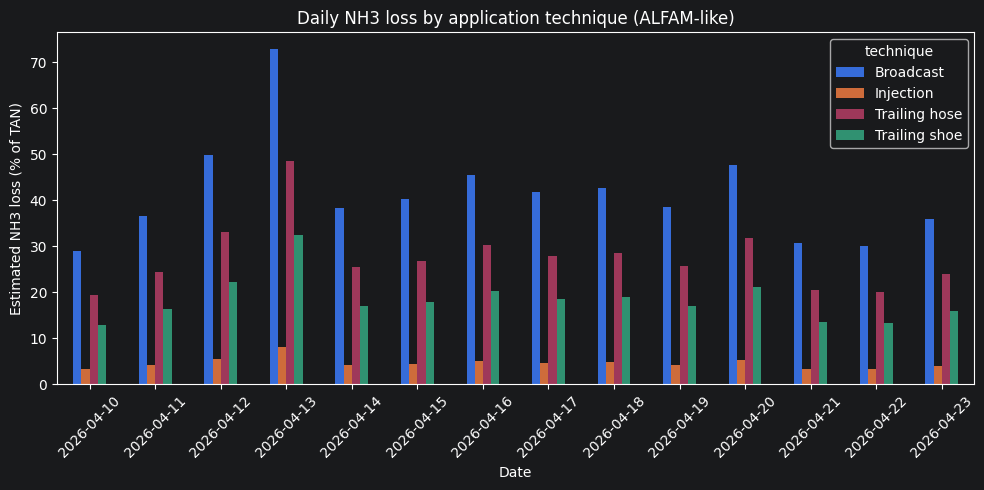

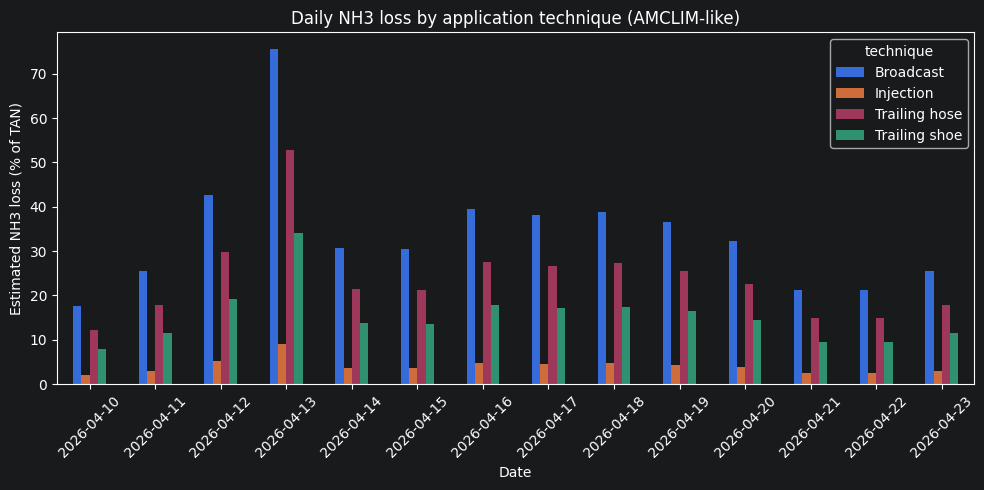

method        date      technique  ALFAM-like  AMCLIM-like  difference
0       2026-04-10      Broadcast   28.920297    17.597942  -11.322355
1       2026-04-10      Injection    3.213366     2.111753   -1.101613
2       2026-04-10  Trailing hose   19.280198    12.318560   -6.961638
3       2026-04-10  Trailing shoe   12.853465     7.919074   -4.934391
4       2026-04-11      Broadcast   36.604485    25.603857  -11.000628
5       2026-04-11      Injection    4.067165     3.072463   -0.994702
6       2026-04-11  Trailing hose   24.402990    17.922700   -6.480290
7       2026-04-11  Trailing shoe   16.268660    11.521735   -4.746924
8       2026-04-12      Broadcast   49.754825    42.611203   -7.143622
9       2026-04-12      Injection    5.528314     5.113344   -0.414970
10      2026-04-12  Trailing hose   33.169883    29.827842   -3.342041
11      2026-04-12  Trailing shoe   22.113255    19.175041   -2.938214
12      2026-04-13      Broadcast   72.813414    75.540789    2.727375
13    

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('./open-meteo-48.22N14.70E251m.csv', skiprows=3)

# Parse time
df["time"] = pd.to_datetime(df["time"])
df["date"] = df["time"].dt.date

# Daily weather
daily = df.groupby("date").agg({
    "temperature_2m (°C)": "mean",
    "wind_speed_10m (km/h)": "mean",
    "relative_humidity_2m (%)": "mean"
}).reset_index()

# -------------------------------------------------------------------
# 1) ALFAM-like method
# -------------------------------------------------------------------
# Simple empirical method: base loss by technique, adjusted by weather.
# This is NOT the official ALFAM2 model; it is only ALFAM-style.

alfam_bases = {
    "Broadcast": 45.0,
    "Trailing hose": 30.0,
    "Trailing shoe": 20.0,
    "Injection": 5.0
}

def alfam_like_loss(base, temp, wind, rh):
    loss = base
    loss *= (1 + 0.03 * (temp - 10))      # warmer -> more loss
    loss *= (1 + 0.02 * (wind - 5))       # windier -> more loss
    loss *= (1 - 0.01 * (rh - 60))        # drier air -> more loss
    return max(loss, 0.0)

# -------------------------------------------------------------------
# 2) AMCLIM-like method
# -------------------------------------------------------------------
# Process-style surrogate:
# - start with an emission potential
# - use normalized weather response
# - stronger role for humidity / drying
# - technique acts through exposed surface / contact factor
#
# This is NOT the official AMCLIM model; it is a lightweight
# process-inspired approximation.

amclim_factors = {
    "Broadcast": 1.00,
    "Trailing hose": 0.70,
    "Trailing shoe": 0.45,
    "Injection": 0.12
}

def amclim_like_loss(temp, wind, rh, technique_factor):
    # Temperature response (Q10-style, mild)
    f_temp = 1.08 ** (temp - 10)

    # Wind response (mass transfer)
    f_wind = 1 + 0.015 * max(wind - 3, 0)

    # Dryness response: lower RH => more volatilization
    dryness = max(0, (80 - rh) / 20)  # 0 at RH>=80, 1 at RH=60, etc.
    f_dry = 1 + 0.25 * dryness

    # Reference emission potential (% TAN)
    base_potential = 28.0

    loss = base_potential * technique_factor * f_temp * f_wind * f_dry
    return max(loss, 0.0)

# -------------------------------------------------------------------
# Run both methods
# -------------------------------------------------------------------
rows = []

for _, row in daily.iterrows():
    temp = row["temperature_2m (°C)"]
    wind = row["wind_speed_10m (km/h)"]
    rh = row["relative_humidity_2m (%)"]

    for tech in alfam_bases:
        rows.append({
            "date": row["date"],
            "technique": tech,
            "method": "ALFAM-like",
            "loss": alfam_like_loss(alfam_bases[tech], temp, wind, rh)
        })

        rows.append({
            "date": row["date"],
            "technique": tech,
            "method": "AMCLIM-like",
            "loss": amclim_like_loss(temp, wind, rh, amclim_factors[tech])
        })

res_df = pd.DataFrame(rows)

# -------------------------------------------------------------------
# Plot comparison
# -------------------------------------------------------------------
for method in ["ALFAM-like", "AMCLIM-like"]:
    pivot = res_df[res_df["method"] == method].pivot(
        index="date", columns="technique", values="loss"
    )

    ax = pivot.plot(kind="bar", figsize=(10, 5))
    ax.set_xlabel("Date")
    ax.set_ylabel("Estimated NH3 loss (% of TAN)")
    ax.set_title(f"Daily NH3 loss by application technique ({method})")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Optional: method-vs-method summary
summary = res_df.pivot_table(
    index=["date", "technique"],
    columns="method",
    values="loss"
).reset_index()

summary["difference"] = summary["AMCLIM-like"] - summary["ALFAM-like"]
print(summary)

In [6]:
import docker
client = docker.from_env()

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import subprocess
import tempfile
from pathlib import Path

# -----------------------------
# USER SETTINGS
# -----------------------------
csv_file = Path("./open-meteo-48.22N14.70E251m.csv")

# Actual slurry application time
application_time = pd.Timestamp("2026-04-10 06:00:00")

# How long to simulate after spreading
hours_after_application = 168  # 7 days

# ALFAM2 manure/application inputs
TAN_app = 60.0          # kg TAN/ha
man_dm = 6.0            # slurry dry matter, %
man_ph = 7.5            # slurry pH
man_source_pig = False  # False = cattle/other, True = pig

# ALFAM2 application method codes:
# bc = broadcast
# ts = trailing shoe
# os = open-slot injection
# cs = closed-slot injection
app_mthd = "bc"

# -----------------------------
# READ YOUR WEATHER CSV
# -----------------------------
# Your file has:
# line 1: metadata header
# line 2: metadata values
# line 3: blank
# line 4: actual weather header
df = pd.read_csv(csv_file, skiprows=3)

df["time"] = pd.to_datetime(df["time"])
df = df.sort_values("time").reset_index(drop=True)

# Keep only weather from application onward
end_time = application_time + pd.Timedelta(hours=hours_after_application)
df = df[(df["time"] >= application_time) & (df["time"] <= end_time)].copy()

if df.empty:
    raise ValueError("No hourly weather rows found in the selected period.")

# -----------------------------
# BUILD ALFAM2 INPUT
# -----------------------------
# cumulative time in hours since application
df["ct"] = (df["time"] - application_time).dt.total_seconds() / 3600.0

# ALFAM2 expects wind near 2 m.
# Your file has 10 m wind speed in km/h.
# First convert km/h -> m/s
df["wind_10m_ms"] = df["wind_speed_10m (km/h)"] / 3.6

# Optional rough conversion from 10 m wind to 2 m wind using a log-like power law
# This is still an approximation, but better than passing km/h directly.
df["wind.2m"] = df["wind_10m_ms"] * (2 / 10) ** 0.14

# ALFAM2 examples often use wind.sqrt
df["wind.sqrt"] = np.sqrt(df["wind.2m"].clip(lower=0))

# Rainfall inputs
# Your file already has hourly precipitation in mm
df["rain.rate"] = df["precipitation (mm)"]     # mm per hour step
df["rain.cum"] = df["rain.rate"].cumsum()      # cumulative mm since application

# Build official-style ALFAM2 input frame
alfam_input = pd.DataFrame({
    "ct": df["ct"],
    "TAN.app": TAN_app,
    "air.temp": df["temperature_2m (°C)"],
    "wind.2m": df["wind.2m"],
    "wind.sqrt": df["wind.sqrt"],
    "rain.rate": df["rain.rate"],
    "rain.cum": df["rain.cum"],
    "man.dm": man_dm,
    "man.ph": man_ph,
    "man.source.pig": man_source_pig,
    "app.mthd": app_mthd,
})

# -----------------------------
# SAVE INPUT FOR R
# -----------------------------
tmpdir = Path(tempfile.mkdtemp())
inp_csv = tmpdir / "alfam2_input.csv"
out_csv = tmpdir / "alfam2_output.csv"
r_script = tmpdir / "run_alfam2.R"

alfam_input.to_csv(inp_csv, index=False)

# -----------------------------
# OFFICIAL ALFAM2 RUN IN R
# -----------------------------
r_code = f"""
library(ALFAM2)

dat <- read.csv("{inp_csv.as_posix()}")

pred <- alfam2(
  dat = dat,
  app.name = "TAN.app",
  time.name = "ct",
  value = "emis",
  warn = TRUE
)

write.csv(pred, "{out_csv.as_posix()}", row.names = FALSE)
"""

r_script.write_text(r_code, encoding="utf-8")

# -----------------------------
# RUN R SCRIPT
# -----------------------------
# Requires:
#   1) R installed
#   2) install.packages("ALFAM2")
subprocess.run(["Rscript", str(r_script)], check=True)

# -----------------------------
# LOAD RESULTS
# -----------------------------
pred = pd.read_csv(out_csv)

print(pred.columns)
print(pred.head())

# -----------------------------
# PLOT RESULTS
# -----------------------------
# ALFAM2 output commonly includes predicted emission columns.
# Try to find the main numeric emission column automatically.
candidate_cols = [c for c in pred.columns if "emis" in c.lower() or "fitted" in c.lower()]

if not candidate_cols:
    raise ValueError(
        f"Could not identify an emission column in ALFAM2 output. "
        f"Available columns: {list(pred.columns)}"
    )

ycol = candidate_cols[0]

plt.figure(figsize=(10, 5))
plt.plot(df["time"], pred[ycol])
plt.xlabel("Time")
plt.ylabel("Predicted NH3 emission")
plt.title(f"ALFAM2 hourly NH3 emission ({app_mthd})")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

FileNotFoundError: [WinError 2] Das System kann die angegebene Datei nicht finden